In [ ]:
import numpy as np

In [ ]:
!pip install --upgrade pip
!pip install torch torchvision opencv-python pillow timm matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
import os
os.rename("Free Road ST.jpg", "input.jpg")

In [ ]:
import torch
from PIL import Image
import numpy as np
import cv2


In [ ]:
# from google.colab import files
# uploaded = files.upload()   # click "Choose Files" and select your image

# # If uploaded filename isn't input.jpg, rename the first uploaded file to input.jpg
# import os
# for fn in uploaded.keys():
#     if fn != "input.jpg":
#         try:
#             os.rename(fn, "input.jpg")
#             print(f"Renamed {fn} -> input.jpg")
#         except Exception as e:
#             print("File rename error:", e)
#     else:
#         print("input.jpg already uploaded")


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-4287964116.py", line 2, in <cell line: 0>
    uploaded = files.upload()   # click "Choose Files" and select your image
               ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/google/colab/files.py", line 72, in upload
    uploaded_files = _upload_files(multiple=True)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/google/colab/files.py", line 164, in _upload_files
    result = _output.eval_js(
             ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/google/colab/output/_js.py", line 40, in eval_js
    return _message.read_reply_from_input(request_id, timeout_sec)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/

TypeError: object of type 'NoneType' has no len()

Input image size: (970, 727)


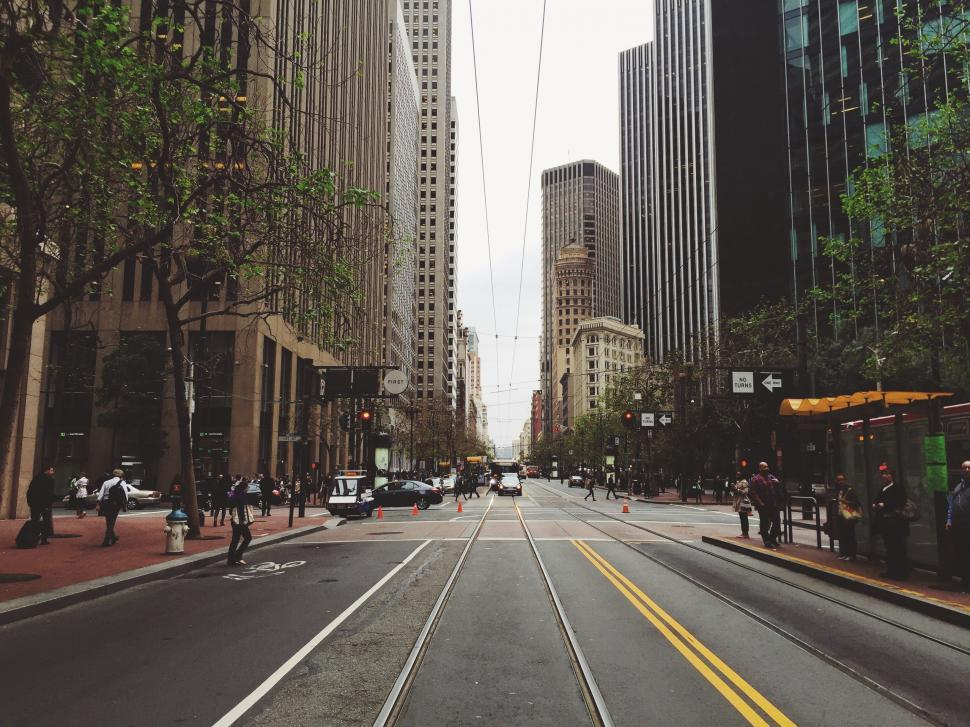

In [ ]:
from IPython.display import display
from PIL import Image

img = Image.open("input.jpg")
print("Input image size:", img.size)
display(img)


Saved preprocessed image as input_pre.jpg


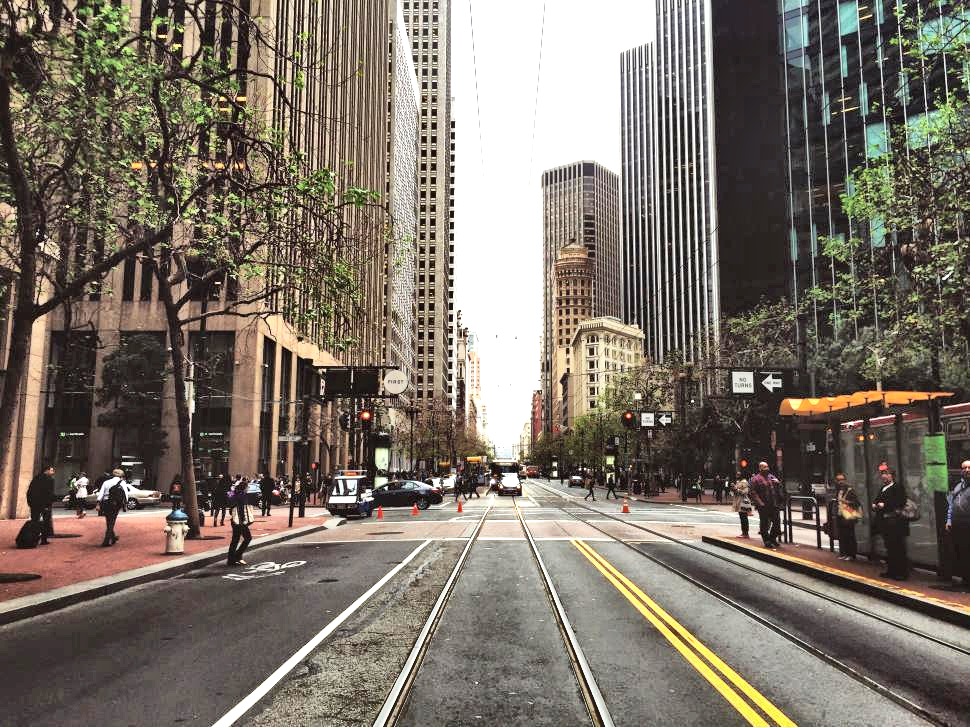

In [ ]:
from PIL import Image, ImageEnhance
import cv2
import numpy as np

# Parameters: tune these if needed
BRIGHTNESS = 1.25   # >1 = brighter
CONTRAST = 1.15     # >1 = more contrast
USE_CLAHE = True    # True = apply CLAHE on the luminance channel
CLAHE_CLIP = 2.0
CLAHE_TILE = (8,8)

# Load
img = Image.open("input.jpg").convert("RGB")

# Enhance brightness & contrast
img = ImageEnhance.Brightness(img).enhance(BRIGHTNESS)
img = ImageEnhance.Contrast(img).enhance(CONTRAST)


if USE_CLAHE:
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(img_cv, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    img_cv2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)
    img = Image.fromarray(cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB))

# Save preprocessed image
img.save("input_pre.jpg")
print("Saved preprocessed image as input_pre.jpg")
display(img)


In [ ]:
import torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# === Settings ===
MODEL_TYPE = "DPT_Hybrid"  # or "DPT_Large"
INPUT_IMAGE = "input_pre.jpg"  # use preprocessed image
OUTPUT_DEPTH_RAW = "depth_raw.png"   # raw normalized depth visualization
OUTPUT_DEPTH = "depth.png"           # normalized uint8 depth
USE_GPU = torch.cuda.is_available()

print("Using GPU:", USE_GPU)
print("Model:", MODEL_TYPE)

# === Load model & transforms ===
midas = torch.hub.load("intel-isl/MiDaS", MODEL_TYPE)
transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
if MODEL_TYPE in ["DPT_Large", "DPT_Hybrid"]:
    transform = transforms.dpt_transform
else:
    transform = transforms.small_transform

midas.eval()
if USE_GPU:
    midas.to("cuda")

# === Load and prepare image ===
img = Image.open(INPUT_IMAGE).convert("RGB")
input_batch = transform(img).unsqueeze(0)
if USE_GPU:
    input_batch = input_batch.to("cuda")

# === Inference ===
with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.size[::-1],
        mode="bicubic",
        align_corners=False
    ).squeeze()

# === Convert to numpy and normalize ===
depth = prediction.cpu().numpy()
d_min, d_max = depth.min(), depth.max()
if d_max - d_min > 1e-6:
    norm = (depth - d_min) / (d_max - d_min)
else:
    norm = depth * 0.0

# Save raw float-normalized visualization and uint8 depth
cv2.imwrite(OUTPUT_DEPTH_RAW, (norm * 255).astype("uint8"))
cv2.imwrite(OUTPUT_DEPTH, (norm * 255).astype("uint8"))
print("Saved:", OUTPUT_DEPTH_RAW, OUTPUT_DEPTH)

# Show side-by-side input & depth
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Input (preprocessed)"); plt.axis('off')
plt.imshow(img)
plt.subplot(1,2,2); plt.title("Depth (normalized)"); plt.axis('off')
plt.imshow(norm, cmap='gray')
plt.show()


In [ ]:
from google.colab import files
files.download("depth.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>